In [1]:
# Paths to docked pose folders (using Linux paths)
autodock_poses_dir = "/home/manndo/MasterProject/docking_ready/docking"
diffdock_poses_dir = "/home/manndo/MasterProject/diffdock_results"
equibind_poses_dir = "/home/manndo/MasterProject/equibind_docked_poses"

# Optional: protein files for intermolecular distance checks
proteins_dir = "/home/manndo/MasterProject/docking_ready"

In [2]:
"""
Overview: Pose Counts by Docking Method and Protein-Ligand Combination
This cell analyzes all docking results directories and creates a summary table
"""
import pandas as pd
from pathlib import Path
import re

def count_autodock_poses():
    """Count AutoDock Vina poses from PDBQT files"""
    autodock_data = []
    base_path = Path(autodock_poses_dir)
    
    for pdbqt_file in base_path.glob("*_vina_out.pdbqt"):
        stem = pdbqt_file.stem.replace("_vina_out", "")
        parts = stem.split("__")
        
        if len(parts) == 2:
            protein, ligand = parts
            
            # Count MODEL entries in PDBQT file
            with open(pdbqt_file, 'r') as f:
                content = f.read()
                pose_count = content.count('MODEL')
                if pose_count == 0:
                    pose_count = 1  # Single pose file without MODEL markers
            
            autodock_data.append({
                "Protein": protein,
                "Ligand": ligand,
                "AutoDock_Vina": pose_count
            })
    
    return pd.DataFrame(autodock_data)


def count_diffdock_poses():
    """Count DiffDock poses from SDF files in subdirectories"""
    diffdock_data = []
    base_path = Path(diffdock_poses_dir)
    
    for subdir in base_path.iterdir():
        if not subdir.is_dir():
            continue
        # Skip helper directories
        if "_ligand__" in subdir.name or subdir.name in ["prepared_proteins", "converted_pdbqt"]:
            continue
        
        parts = subdir.name.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            
            # Count all SDF files in subdirectory (including complex_* folders)
            pose_count = len(list(subdir.glob("**/*.sdf")))
            
            if pose_count > 0:
                diffdock_data.append({
                    "Protein": protein,
                    "Ligand": ligand,
                    "DiffDock": pose_count
                })
    
    return pd.DataFrame(diffdock_data)


def count_equibind_poses():
    """Count EquiBind poses from SDF files (excluding pymol variants)"""
    equibind_data = []
    base_path = Path(equibind_poses_dir)
    
    for subdir in base_path.iterdir():
        if not subdir.is_dir():
            continue
        # Skip pymol export/fixed variants for main count
        if "_pymol" in subdir.name:
            continue
        
        parts = subdir.name.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            
            # Count SDF files
            pose_count = len(list(subdir.glob("*.sdf")))
            
            if pose_count > 0:
                equibind_data.append({
                    "Protein": protein,
                    "Ligand": ligand,
                    "EquiBind": pose_count
                })
    
    return pd.DataFrame(equibind_data)


# Collect pose counts from all methods
print("=" * 100)
print("DOCKING POSES OVERVIEW")
print("=" * 100)

print("\nCollecting pose counts from all docking methods...\n")

df_autodock = count_autodock_poses()
df_diffdock = count_diffdock_poses()
df_equibind = count_equibind_poses()

print(f"  AutoDock Vina: {len(df_autodock)} protein-ligand combinations")
print(f"  DiffDock:      {len(df_diffdock)} protein-ligand combinations")
print(f"  EquiBind:      {len(df_equibind)} protein-ligand combinations")

# Merge all three methods into one table
if not df_autodock.empty:
    df_combined = df_autodock
    if not df_diffdock.empty:
        df_combined = df_combined.merge(df_diffdock, on=["Protein", "Ligand"], how="outer")
    if not df_equibind.empty:
        df_combined = df_combined.merge(df_equibind, on=["Protein", "Ligand"], how="outer")
elif not df_diffdock.empty:
    df_combined = df_diffdock
    if not df_equibind.empty:
        df_combined = df_combined.merge(df_equibind, on=["Protein", "Ligand"], how="outer")
else:
    df_combined = df_equibind if not df_equibind.empty else pd.DataFrame()

if not df_combined.empty:
    # Fill NaN with 0 and convert to int
    df_combined = df_combined.fillna(0)
    for col in ["AutoDock_Vina", "DiffDock", "EquiBind"]:
        if col in df_combined.columns:
            df_combined[col] = df_combined[col].astype(int)
    
    # Add total column
    method_cols = [c for c in ["AutoDock_Vina", "DiffDock", "EquiBind"] if c in df_combined.columns]
    df_combined["Total"] = df_combined[method_cols].sum(axis=1)
    
    # Sort by protein, then ligand
    df_combined = df_combined.sort_values(["Protein", "Ligand"])
    
    # Display full table
    print("\n" + "=" * 100)
    print("POSE COUNTS BY PROTEIN-LIGAND COMBINATION")
    print("=" * 100)
    print(df_combined.to_string(index=False))
    
    # Summary statistics
    print("\n" + "=" * 100)
    print("SUMMARY STATISTICS")
    print("=" * 100)
    print(f"\nTotal unique protein-ligand combinations: {len(df_combined)}")
    print(f"\nTotal poses by method:")
    for col in method_cols:
        print(f"  {col}: {df_combined[col].sum():,} poses")
    print(f"  Combined Total: {df_combined['Total'].sum():,} poses")
    
    print(f"\nUnique proteins: {df_combined['Protein'].nunique()}")
    print(f"Unique ligands: {df_combined['Ligand'].nunique()}")
    
    # Breakdown by ligand
    print("\n" + "-" * 100)
    print("POSES BY LIGAND")
    print("-" * 100)
    ligand_summary = df_combined.groupby("Ligand")[method_cols + ["Total"]].sum()
    print(ligand_summary.to_string())
    
    # Breakdown by protein
    print("\n" + "-" * 100)
    print("POSES BY PROTEIN")
    print("-" * 100)
    protein_summary = df_combined.groupby("Protein")[method_cols + ["Total"]].sum()
    print(protein_summary.to_string())
    
    # Save to CSV
    output_file = Path("/home/manndo/MasterProject/posebusters_results") / "pose_counts_overview.csv"
    output_file.parent.mkdir(exist_ok=True)
    df_combined.to_csv(output_file, index=False)
    print(f"\n" + "=" * 100)
    print(f"Table saved to: {output_file}")
    print("=" * 100)
    
else:
    print("\nNo docking results found!")


DOCKING POSES OVERVIEW


  AutoDock Vina: 268 protein-ligand combinations
  DiffDock:      19 protein-ligand combinations
  EquiBind:      21 protein-ligand combinations

POSE COUNTS BY PROTEIN-LIGAND COMBINATION
                                       Protein               Ligand  AutoDock_Vina  DiffDock  EquiBind  Total
                          Orai1WT-MDSnap-Fr300         2abp-nh2-OPT              9        11         5     25
                          Orai1WT-MDSnap-Fr300        2abp-nh3p-OPT              0        11         3     14
                          Orai1WT-MDSnap-Fr300 Synta-66-OPT-Singlet              9        11         4     24
                          Orai1WT-MDSnap-Fr300  gsk7975a-deprot-OPT              9        11         2     22
                          Orai1WT-MDSnap-Fr300    gsk7975a-prot-OPT              9        11         3     23
            Orai1WT-MDSnap-Fr300_spatial_sites         2abp-nh2-OPT              0         0         1      1
                 

In [3]:
"""
Create Filtered Subset of Docked Poses Based on Protein Prefixes/Postfixes and Docking Tools
=============================================================================================
This routine creates a filtered collection of docked poses with configurable rules:
- Filter by protein name prefixes (e.g., "mgl_", "ob_")
- Filter by protein name postfixes (e.g., "_mgl", "_amber_clean")
- Each prefix/postfix can be set to True (include) or False (exclude)
- Optionally strip matched prefixes/postfixes from protein names in the output

The routine is configurable with:
- protein_prefix_filters: dict mapping docking tool -> {prefix: True/False} or None for all
- protein_postfix_filters: dict mapping docking tool -> {postfix: True/False} or None for all
- docking_tools: list of docking tools to include
- STRIP_MATCHED_AFFIXES: boolean to remove matched prefixes/postfixes from protein names
"""
import pandas as pd
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import shutil

# ============================================================================
# CONFIGURATION
# ============================================================================

# Define PREFIX filters for each docking tool
# Use dict with {prefix: True/False} to enable/disable filtering by specific prefixes
# - True = INCLUDE poses with this prefix
# - False = EXCLUDE poses with this prefix
# - None = No prefix filtering (check postfix only)
PROTEIN_PREFIX_FILTERS: Dict[str, Optional[Dict[str, bool]]] = {
    "autodock_vina": {"mgl_": True},      # No prefix filtering for AutoDock
    "diffdock": None,           # No prefix filtering for DiffDock
    "equibind": None,           # No prefix filtering for EquiBind
}

# Define POSTFIX filters for each docking tool
# Use dict with {postfix: True/False} to enable/disable filtering by specific postfixes
# - True = INCLUDE poses with this postfix
# - False = EXCLUDE poses with this postfix
# - None = No postfix filtering (check prefix only)
PROTEIN_POSTFIX_FILTERS: Dict[str, Optional[Dict[str, bool]]] = {
    "autodock_vina": {
        "_clean": False,                    # Exclude poses docked with cleaned files
        "_clean_pm_saved": False,           # Exclude cleaned processed files
        "_pm_saved": False,                 # Exclude processed files
        "_pymol_export": False,            # Exclude pymol exported files
        "_pymol_fixed": False,              # Exclude pymol fixed files
        "_amber": False,                    # Exclude poses docked with Amber converted proteins
        "_amber_pm_saved": False,           # Exclude amber processed files
        "_amber_clean_pm_saved": False,     # Exclude amber processed files
        "_amber_clean": False,              # Exclude amber clean files
    },
    "diffdock": None, 
    "equibind": None,         # Exclude amber clean files
}

# STRIP MATCHED AFFIXES FROM PROTEIN NAMES
# When True, removes the matched prefix and postfix from protein names in the output
# Example: "mgl_Orai1WT-MDSnap-Fr300_amber_clean" -> "Orai1WT-MDSnap-Fr300"
STRIP_MATCHED_AFFIXES: bool = True

# List of docking tools to include in the subset
DOCKING_TOOLS = ["autodock_vina", "diffdock", "equibind"]

# Output directory for the filtered subset
SUBSET_OUTPUT_DIR = Path("/home/manndo/MasterProject/posebusters_results/filtered_poses")


# ============================================================================
# FILTERING FUNCTIONS
# ============================================================================

def check_prefix_filter(name: str, prefix_config: Optional[Dict[str, bool]]) -> Tuple[bool, str]:
    """
    Check if a name passes the prefix filter configuration.
    
    Args:
        name: The protein/file name to check
        prefix_config: Dict of {prefix: True/False} or None to skip prefix filtering
        
    Returns:
        Tuple of (passes_filter: bool, matched_prefix: str)
    """
    # If no filter config, pass through (no prefix filtering)
    if prefix_config is None:
        return True, "no_prefix_filter"
    
    # Check each prefix in the config
    for prefix, include in prefix_config.items():
        if name.startswith(prefix):
            return include, prefix
    
    # If no prefix matched, check if we have any True filters
    has_inclusion_filter = any(v for v in prefix_config.values())
    
    if has_inclusion_filter:
        # Has inclusion filters but didn't match any -> exclude
        return False, "no_prefix_match"
    else:
        # Only exclusion filters and didn't match any -> include
        return True, "no_prefix"


def check_postfix_filter(name: str, postfix_config: Optional[Dict[str, bool]]) -> Tuple[bool, str]:
    """
    Check if a name passes the postfix filter configuration.
    
    Args:
        name: The protein/file name to check
        postfix_config: Dict of {postfix: True/False} or None to skip postfix filtering
        
    Returns:
        Tuple of (passes_filter: bool, matched_postfix: str)
    """
    # If no filter config, pass through (no postfix filtering)
    if postfix_config is None:
        return True, "no_postfix_filter"
    
    # Check each postfix in the config (longer postfixes first for proper matching)
    sorted_postfixes = sorted(postfix_config.keys(), key=len, reverse=True)
    for postfix in sorted_postfixes:
        include = postfix_config[postfix]
        if name.endswith(postfix):
            return include, postfix
    
    # If no postfix matched, check if we have any True filters
    has_inclusion_filter = any(v for v in postfix_config.values())
    
    if has_inclusion_filter:
        # Has inclusion filters but didn't match any -> exclude
        return False, "no_postfix_match"
    else:
        # Only exclusion filters and didn't match any -> include
        return True, "no_postfix"


def check_combined_filter(
    name: str, 
    prefix_config: Optional[Dict[str, bool]], 
    postfix_config: Optional[Dict[str, bool]]
) -> Tuple[bool, str, str]:
    """
    Check if a name passes both prefix AND postfix filter configurations.
    Both must pass for the item to be included.
    
    Args:
        name: The protein/file name to check
        prefix_config: Dict of {prefix: True/False} or None
        postfix_config: Dict of {postfix: True/False} or None
        
    Returns:
        Tuple of (passes_filter: bool, matched_prefix: str, matched_postfix: str)
    """
    passes_prefix, matched_prefix = check_prefix_filter(name, prefix_config)
    passes_postfix, matched_postfix = check_postfix_filter(name, postfix_config)
    
    # Both must pass
    passes_filter = passes_prefix and passes_postfix
    
    return passes_filter, matched_prefix, matched_postfix


def strip_affixes_from_name(
    name: str, 
    matched_prefix: str, 
    matched_postfix: str
) -> str:
    """
    Remove the matched prefix and postfix from a protein name.
    
    Args:
        name: The original protein name
        matched_prefix: The prefix that was matched (or "no_prefix_filter", "no_prefix", etc.)
        matched_postfix: The postfix that was matched (or "no_postfix_filter", "no_postfix", etc.)
        
    Returns:
        The protein name with matched affixes removed
    """
    result = name
    
    # Strip prefix if it was actually matched (not a "no_*" placeholder)
    if matched_prefix and not matched_prefix.startswith("no_"):
        if result.startswith(matched_prefix):
            result = result[len(matched_prefix):]
    
    # Strip postfix if it was actually matched (not a "no_*" placeholder)
    if matched_postfix and not matched_postfix.startswith("no_"):
        if result.endswith(matched_postfix):
            result = result[:-len(matched_postfix)]
    
    return result


def filter_autodock_vina_poses(
    poses_dir: str,
    prefix_config: Optional[Dict[str, bool]] = None,
    postfix_config: Optional[Dict[str, bool]] = None,
    file_postfix: Optional[str] = "_vina_out.pdbqt",
    strip_affixes: bool = False
) -> List[Dict]:
    """
    Filter AutoDock Vina poses based on protein prefixes and postfixes.
    
    Args:
        poses_dir: Directory containing PDBQT output files
        prefix_config: Dict of {prefix: True/False} or None for no prefix filtering
        postfix_config: Dict of {postfix: True/False} or None for no postfix filtering
        file_postfix: File postfix to look for
        strip_affixes: Whether to strip matched prefixes/postfixes from protein names
    
    Returns:
        List of dicts with pose information
    """
    filtered_poses = []
    base_path = Path(poses_dir)
    
    for pdbqt_file in base_path.glob(f"*{file_postfix}"):
        stem = pdbqt_file.stem.replace("_vina_out", "")
        parts = stem.split("__")
        
        if len(parts) != 2:
            continue
            
        protein, ligand = parts
        
        # Apply combined prefix and postfix filter
        passes_filter, matched_prefix, matched_postfix = check_combined_filter(
            protein, prefix_config, postfix_config
        )
        if not passes_filter:
            continue
        
        # Optionally strip affixes from protein name
        protein_original = protein
        if strip_affixes:
            protein = strip_affixes_from_name(protein, matched_prefix, matched_postfix)
        
        # Count poses in file
        with open(pdbqt_file, 'r') as f:
            content = f.read()
            pose_count = content.count('MODEL')
            if pose_count == 0:
                pose_count = 1
        
        filtered_poses.append({
            "docking_tool": "AutoDock_Vina",
            "protein": protein,
            "protein_original": protein_original,
            "ligand": ligand,
            "pose_count": pose_count,
            "file_path": str(pdbqt_file),
            "prefix_match": matched_prefix,
            "postfix_match": matched_postfix
        })
    
    return filtered_poses


def filter_diffdock_poses(
    poses_dir: str,
    prefix_config: Optional[Dict[str, bool]] = None,
    postfix_config: Optional[Dict[str, bool]] = None,
    strip_affixes: bool = False
) -> List[Dict]:
    """
    Filter DiffDock poses based on protein prefixes and postfixes.
    
    Args:
        poses_dir: Directory containing DiffDock result subdirectories
        prefix_config: Dict of {prefix: True/False} or None for no prefix filtering
        postfix_config: Dict of {postfix: True/False} or None for no postfix filtering
        strip_affixes: Whether to strip matched prefixes/postfixes from protein names
    
    Returns:
        List of dicts with pose information
    """
    filtered_poses = []
    base_path = Path(poses_dir)
    
    for subdir in base_path.iterdir():
        if not subdir.is_dir():
            continue
        # Skip helper directories
        if "_ligand__" in subdir.name or subdir.name in ["prepared_proteins", "converted_pdbqt"]:
            continue
        
        parts = subdir.name.split("__")
        if len(parts) != 2:
            continue
            
        ligand, protein = parts
        
        # Apply combined prefix and postfix filter
        passes_filter, matched_prefix, matched_postfix = check_combined_filter(
            protein, prefix_config, postfix_config
        )
        if not passes_filter:
            continue
        
        # Optionally strip affixes from protein name
        protein_original = protein
        if strip_affixes:
            protein = strip_affixes_from_name(protein, matched_prefix, matched_postfix)
        
        # Count SDF files
        pose_count = len(list(subdir.glob("**/*.sdf")))
        
        if pose_count > 0:
            filtered_poses.append({
                "docking_tool": "DiffDock",
                "protein": protein,
                "protein_original": protein_original,
                "ligand": ligand,
                "pose_count": pose_count,
                "file_path": str(subdir),
                "prefix_match": matched_prefix,
                "postfix_match": matched_postfix
            })
    
    return filtered_poses


def filter_equibind_poses(
    poses_dir: str,
    prefix_config: Optional[Dict[str, bool]] = None,
    postfix_config: Optional[Dict[str, bool]] = None,
    strip_affixes: bool = False
) -> List[Dict]:
    """
    Filter EquiBind poses based on protein prefixes and postfixes.
    
    Args:
        poses_dir: Directory containing EquiBind result subdirectories
        prefix_config: Dict of {prefix: True/False} or None for no prefix filtering
        postfix_config: Dict of {postfix: True/False} or None for no postfix filtering
        strip_affixes: Whether to strip matched prefixes/postfixes from protein names
    
    Returns:
        List of dicts with pose information
    """
    filtered_poses = []
    base_path = Path(poses_dir)
    
    for subdir in base_path.iterdir():
        if not subdir.is_dir():
            continue
        # Skip pymol variants
        if "_pymol" in subdir.name:
            continue
        
        parts = subdir.name.split("__")
        if len(parts) != 2:
            continue
            
        ligand, protein = parts
        
        # Apply combined prefix and postfix filter
        passes_filter, matched_prefix, matched_postfix = check_combined_filter(
            protein, prefix_config, postfix_config
        )
        if not passes_filter:
            continue
        
        # Optionally strip affixes from protein name
        protein_original = protein
        if strip_affixes:
            protein = strip_affixes_from_name(protein, matched_prefix, matched_postfix)
        
        # Count SDF files
        pose_count = len(list(subdir.glob("*.sdf")))
        
        if pose_count > 0:
            filtered_poses.append({
                "docking_tool": "EquiBind",
                "protein": protein,
                "protein_original": protein_original,
                "ligand": ligand,
                "pose_count": pose_count,
                "file_path": str(subdir),
                "prefix_match": matched_prefix,
                "postfix_match": matched_postfix
            })
    
    return filtered_poses


def format_filter_config(config: Optional[Dict[str, bool]], filter_type: str = "filter") -> str:
    """Format filter config for display"""
    if config is None:
        return f"no {filter_type} filter"
    
    included = [k for k, v in config.items() if v]
    excluded = [k for k, v in config.items() if not v]
    
    parts = []
    if included:
        parts.append(f"include: {', '.join(included)}")
    if excluded:
        parts.append(f"exclude: {', '.join(excluded)}")
    
    return "; ".join(parts) if parts else f"no {filter_type} filter"


def create_filtered_pose_subset(
    autodock_dir: str,
    diffdock_dir: str,
    equibind_dir: str,
    prefix_filters: Dict[str, Optional[Dict[str, bool]]] = PROTEIN_PREFIX_FILTERS,
    postfix_filters: Dict[str, Optional[Dict[str, bool]]] = PROTEIN_POSTFIX_FILTERS,
    tools_to_include: List[str] = DOCKING_TOOLS,
    output_dir: Optional[Path] = None,
    copy_files: bool = False,
    strip_affixes: bool = False
) -> Tuple[pd.DataFrame, Dict[str, int]]:
    """
    Create a filtered subset of docked poses based on protein prefixes/postfixes and docking tools.
    
    Args:
        autodock_dir: Path to AutoDock Vina results
        diffdock_dir: Path to DiffDock results
        equibind_dir: Path to EquiBind results
        prefix_filters: Dict mapping tool name -> {prefix: True/False} or None
        postfix_filters: Dict mapping tool name -> {postfix: True/False} or None
        tools_to_include: List of tools to include
        output_dir: Optional directory to copy filtered files to
        copy_files: Whether to copy files to output_dir
        strip_affixes: Whether to strip matched prefixes/postfixes from protein names
    
    Returns:
        Tuple of (DataFrame with all filtered poses, summary dict with counts)
    """
    all_poses = []
    
    # Process each docking tool
    if "autodock_vina" in tools_to_include:
        prefix_cfg = prefix_filters.get("autodock_vina")
        postfix_cfg = postfix_filters.get("autodock_vina")
        poses = filter_autodock_vina_poses(
            autodock_dir, 
            prefix_config=prefix_cfg, 
            postfix_config=postfix_cfg,
            strip_affixes=strip_affixes
        )
        all_poses.extend(poses)
        print(f"  AutoDock Vina: {len(poses)} filtered combinations")
        print(f"      Prefix:  {format_filter_config(prefix_cfg, 'prefix')}")
        print(f"      Postfix: {format_filter_config(postfix_cfg, 'postfix')}")
    
    if "diffdock" in tools_to_include:
        prefix_cfg = prefix_filters.get("diffdock")
        postfix_cfg = postfix_filters.get("diffdock")
        poses = filter_diffdock_poses(
            diffdock_dir, 
            prefix_config=prefix_cfg, 
            postfix_config=postfix_cfg,
            strip_affixes=strip_affixes
        )
        all_poses.extend(poses)
        print(f"  DiffDock:      {len(poses)} filtered combinations")
        print(f"      Prefix:  {format_filter_config(prefix_cfg, 'prefix')}")
        print(f"      Postfix: {format_filter_config(postfix_cfg, 'postfix')}")
    
    if "equibind" in tools_to_include:
        prefix_cfg = prefix_filters.get("equibind")
        postfix_cfg = postfix_filters.get("equibind")
        poses = filter_equibind_poses(
            equibind_dir, 
            prefix_config=prefix_cfg, 
            postfix_config=postfix_cfg,
            strip_affixes=strip_affixes
        )
        all_poses.extend(poses)
        print(f"  EquiBind:      {len(poses)} filtered combinations")
        print(f"      Prefix:  {format_filter_config(prefix_cfg, 'prefix')}")
        print(f"      Postfix: {format_filter_config(postfix_cfg, 'postfix')}")
    
    # Create DataFrame
    df = pd.DataFrame(all_poses)
    
    if df.empty:
        print("\nNo poses matched the filter criteria!")
        return df, {}
    
    # Calculate summary statistics
    summary = {
        "total_combinations": len(df),
        "total_poses": df["pose_count"].sum(),
    }
    
    for tool in df["docking_tool"].unique():
        tool_df = df[df["docking_tool"] == tool]
        summary[f"{tool}_combinations"] = len(tool_df)
        summary[f"{tool}_poses"] = tool_df["pose_count"].sum()
    
    # Optionally copy files to output directory
    if copy_files and output_dir:
        output_dir.mkdir(parents=True, exist_ok=True)
        for _, row in df.iterrows():
            src = Path(row["file_path"])
            tool_subdir = output_dir / row["docking_tool"].lower().replace(" ", "_")
            tool_subdir.mkdir(exist_ok=True)
            
            if src.is_file():
                shutil.copy2(src, tool_subdir / src.name)
            elif src.is_dir():
                dest = tool_subdir / src.name
                if dest.exists():
                    shutil.rmtree(dest)
                shutil.copytree(src, dest)
        
        print(f"\nFiles copied to: {output_dir}")
    
    return df, summary


# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 100)
print("CREATING FILTERED POSE SUBSET (Prefix + Postfix Filtering)")
print("=" * 100)
print(f"\nFilter Configuration:")
print(f"\n  AutoDock Vina:")
print(f"    Prefix:  {format_filter_config(PROTEIN_PREFIX_FILTERS.get('autodock_vina'), 'prefix')}")
print(f"    Postfix: {format_filter_config(PROTEIN_POSTFIX_FILTERS.get('autodock_vina'), 'postfix')}")
print(f"\n  DiffDock:")
print(f"    Prefix:  {format_filter_config(PROTEIN_PREFIX_FILTERS.get('diffdock'), 'prefix')}")
print(f"    Postfix: {format_filter_config(PROTEIN_POSTFIX_FILTERS.get('diffdock'), 'postfix')}")
print(f"\n  EquiBind:")
print(f"    Prefix:  {format_filter_config(PROTEIN_PREFIX_FILTERS.get('equibind'), 'prefix')}")
print(f"    Postfix: {format_filter_config(PROTEIN_POSTFIX_FILTERS.get('equibind'), 'postfix')}")
print(f"\n  Strip Matched Affixes: {STRIP_MATCHED_AFFIXES}")
print(f"\nCollecting filtered poses...\n")

# Create filtered subset
df_filtered, summary = create_filtered_pose_subset(
    autodock_dir=autodock_poses_dir,
    diffdock_dir=diffdock_poses_dir,
    equibind_dir=equibind_poses_dir,
    prefix_filters=PROTEIN_PREFIX_FILTERS,
    postfix_filters=PROTEIN_POSTFIX_FILTERS,
    tools_to_include=DOCKING_TOOLS,
    output_dir=SUBSET_OUTPUT_DIR,
    copy_files=False,  # Set to True to copy files
    strip_affixes=STRIP_MATCHED_AFFIXES
)

if not df_filtered.empty:
    # Display results
    print("\n" + "=" * 100)
    print("FILTERED POSE SUBSET SUMMARY")
    print("=" * 100)
    
    print(f"\nTotal filtered combinations: {summary['total_combinations']}")
    print(f"Total poses: {summary['total_poses']:,}")
    
    if STRIP_MATCHED_AFFIXES:
        print(f"\nNote: Protein names have been cleaned (matched prefixes/postfixes removed)")
    
    print("\n" + "-" * 100)
    print("BREAKDOWN BY DOCKING TOOL")
    print("-" * 100)
    
    tool_summary = df_filtered.groupby("docking_tool").agg({
        "pose_count": ["count", "sum"],
        "protein": "nunique",
        "ligand": "nunique"
    }).round(2)
    tool_summary.columns = ["Combinations", "Total Poses", "Unique Proteins", "Unique Ligands"]
    print(tool_summary.to_string())
    
    print("\n" + "-" * 100)
    print("FILTERED POSE DETAILS")
    print("-" * 100)
    
    # Show different columns based on whether affixes were stripped
    if STRIP_MATCHED_AFFIXES:
        display_df = df_filtered[["docking_tool", "protein", "protein_original", "ligand", "pose_count"]].copy()
        display_df = display_df.sort_values(["docking_tool", "protein", "ligand"])
        print("(protein = cleaned name, protein_original = original with affixes)")
    else:
        display_df = df_filtered[["docking_tool", "protein", "ligand", "pose_count", "prefix_match", "postfix_match"]].copy()
        display_df = display_df.sort_values(["docking_tool", "protein", "ligand"])
    print(display_df.to_string(index=False))
    
    # Save to CSV
    output_csv = SUBSET_OUTPUT_DIR.parent / "filtered_poses_subset.csv"
    output_csv.parent.mkdir(exist_ok=True)
    df_filtered.to_csv(output_csv, index=False)
    print(f"\n" + "=" * 100)
    print(f"Filtered subset saved to: {output_csv}")
    print("=" * 100)

# Make df_filtered available for downstream cells
filtered_poses_df = df_filtered

CREATING FILTERED POSE SUBSET (Prefix + Postfix Filtering)

Filter Configuration:

  AutoDock Vina:
    Prefix:  include: mgl_
    Postfix: exclude: _clean, _clean_pm_saved, _pm_saved, _pymol_export, _pymol_fixed, _amber, _amber_pm_saved, _amber_clean_pm_saved, _amber_clean

  DiffDock:
    Prefix:  no prefix filter
    Postfix: no postfix filter

  EquiBind:
    Prefix:  no prefix filter
    Postfix: no postfix filter

  Strip Matched Affixes: True


  AutoDock Vina: 16 filtered combinations
      Prefix:  include: mgl_
      Postfix: exclude: _clean, _clean_pm_saved, _pm_saved, _pymol_export, _pymol_fixed, _amber, _amber_pm_saved, _amber_clean_pm_saved, _amber_clean
  DiffDock:      19 filtered combinations
      Prefix:  no prefix filter
      Postfix: no postfix filter
  EquiBind:      21 filtered combinations
      Prefix:  no prefix filter
      Postfix: no postfix filter

FILTERED POSE SUBSET SUMMARY

Total filtered combinations: 56
Total poses: 431

Note: Protein names have bee

In [4]:
"""
PoseBusters Analysis - Validate docked poses from the FILTERED SUBSET only
Checks: molecule validity, stereochemistry, bond geometry, ring flatness, etc.

NOTE: This cell uses the filtered_poses_df from the previous cell to only validate
poses that match the defined prefix/postfix filter criteria.
"""
import os
import glob
import subprocess
import re
import pandas as pd
from pathlib import Path
from posebusters import PoseBusters

# ============================================================================
# CONFIGURATION
# ============================================================================
# Output directory for results
output_dir = Path("/home/manndo/MasterProject/posebusters_results")
output_dir.mkdir(exist_ok=True)

# Temporary directory for converted PDBQT files
converted_dir = output_dir / "converted_pdbqt"
converted_dir.mkdir(exist_ok=True)

# Use "dock" mode (no crystal ligand reference) or "mol" mode (molecule checks only)
# "dock" includes protein clash checks if protein is provided
# "mol" checks ligand-only properties
CONFIG_MODE = "mol"  # Options: "dock" (with protein), "mol" (ligand only)

# ============================================================================
# PDBQT CONVERSION FUNCTIONS
# ============================================================================

def split_pdbqt_models(pdbqt_file: str) -> list[str]:
    """
    Split a multi-model PDBQT file (from AutoDock Vina) into separate model blocks.
    
    Args:
        pdbqt_file: Path to the PDBQT file containing multiple docked poses
        
    Returns:
        List of strings, each containing one MODEL's content
    """
    with open(pdbqt_file, 'r') as f:
        content = f.read()
    
    models = []
    current_model = []
    in_model = False
    
    for line in content.split('\n'):
        if line.startswith('MODEL'):
            in_model = True
            current_model = [line]
        elif line.startswith('ENDMDL'):
            current_model.append(line)
            models.append('\n'.join(current_model))
            current_model = []
            in_model = False
        elif in_model:
            current_model.append(line)
    
    # If no MODEL/ENDMDL markers, treat entire file as single model
    if not models and content.strip():
        models = [content]
    
    return models


def convert_pdbqt_to_sdf_files(pdbqt_file: str, output_dir: Path) -> list[str]:
    """
    Convert a multi-pose PDBQT file to multiple SDF files using Open Babel.
    
    SDF format is preferred over PDB because it preserves:
    - Bond connectivity and bond orders
    - Formal charges
    - Stereochemistry information
    
    This ensures PoseBusters can properly analyze molecular geometry.
    
    Args:
        pdbqt_file: Path to the input PDBQT file
        output_dir: Directory to save converted SDF files
        
    Returns:
        List of paths to converted SDF files
    """
    pdbqt_path = Path(pdbqt_file)
    base_name = pdbqt_path.stem  # e.g., "Orai1WT-MDSnap-Fr300__2abp-nh2-OPT_vina_out"
    
    # Split the PDBQT file into individual models
    models = split_pdbqt_models(pdbqt_file)
    
    if not models:
        print(f"  Warning: No models found in {pdbqt_file}")
        return []
    
    converted_files = []
    
    for i, model_content in enumerate(models, start=1):
        # Create temporary PDBQT file for single model
        temp_pdbqt = output_dir / f"{base_name}_model{i}.pdbqt"
        output_sdf = output_dir / f"{base_name}_model{i}.sdf"
        
        # Skip if already converted
        if output_sdf.exists():
            converted_files.append(str(output_sdf))
            continue
        
        # Write single model to temp file
        with open(temp_pdbqt, 'w') as f:
            f.write(model_content)
        
        try:
            # Convert using Open Babel (obabel) to SDF format
            # -h adds hydrogens if missing
            # SDF preserves bond information better than PDB
            result = subprocess.run(
                ['obabel', str(temp_pdbqt), '-O', str(output_sdf)],
                capture_output=True,
                text=True
            )
            
            if result.returncode == 0 and output_sdf.exists():
                converted_files.append(str(output_sdf))
            else:
                print(f"  Warning: Failed to convert {temp_pdbqt}: {result.stderr}")
                
        except FileNotFoundError:
            # Open Babel not found, try with RDKit
            try:
                from rdkit import Chem
                from rdkit.Chem import AllChem
                
                # Read PDBQT as PDB (RDKit doesn't directly support PDBQT)
                mol = Chem.MolFromPDBFile(str(temp_pdbqt), removeHs=False, sanitize=False)
                if mol is not None:
                    # Try to sanitize
                    try:
                        Chem.SanitizeMol(mol)
                    except:
                        pass  # Keep unsanitized if it fails
                    
                    writer = Chem.SDWriter(str(output_sdf))
                    writer.write(mol)
                    writer.close()
                    
                    if output_sdf.exists():
                        converted_files.append(str(output_sdf))
                else:
                    print(f"  Warning: RDKit failed to read {temp_pdbqt}")
                    
            except ImportError:
                # Try PyMOL as last resort
                try:
                    from pymol import cmd
                    cmd.reinitialize()
                    cmd.load(str(temp_pdbqt), "mol")
                    cmd.save(str(output_sdf), "mol")
                    cmd.delete("all")
                    if output_sdf.exists():
                        converted_files.append(str(output_sdf))
                except ImportError:
                    print("  Error: No conversion tool available (Open Babel, RDKit, or PyMOL)!")
                    print("  Install with: conda install -c conda-forge openbabel")
                    return []
        
        # Clean up temp PDBQT file
        if temp_pdbqt.exists():
            temp_pdbqt.unlink()
    
    return converted_files


# ============================================================================
# HELPER FUNCTIONS FOR FILTERED SUBSET
# ============================================================================

def collect_poses_from_filtered_subset(filtered_df: pd.DataFrame) -> list[dict]:
    """
    Collect all individual pose files from the filtered subset DataFrame.
    
    This function takes the filtered_poses_df from the previous cell and expands
    it to include all individual pose files (e.g., all SDF files in a DiffDock folder,
    all models from a PDBQT file).
    
    Args:
        filtered_df: DataFrame with columns: docking_tool, protein, ligand, file_path, pose_count
        
    Returns:
        List of dicts with pose information ready for PoseBusters analysis
    """
    all_poses = []
    
    for _, row in filtered_df.iterrows():
        docking_tool = row["docking_tool"]
        protein = row["protein"]
        ligand = row["ligand"]
        file_path = Path(row["file_path"])
        
        if docking_tool == "AutoDock_Vina":
            # Convert PDBQT to SDF files
            if file_path.exists() and file_path.suffix == ".pdbqt":
                print(f"  Converting {file_path.name} to SDF...")
                sdf_files = convert_pdbqt_to_sdf_files(str(file_path), converted_dir)
                
                for sdf_file in sdf_files:
                    sdf_path = Path(sdf_file)
                    model_num = sdf_path.stem.split("_model")[-1] if "_model" in sdf_path.stem else "1"
                    
                    all_poses.append({
                        "method": "autodock",
                        "protein": protein,
                        "ligand": ligand,
                        "pose_file": sdf_file,
                        "pose_name": f"{protein}__{ligand}_pose{model_num}",
                        "original_pdbqt": str(file_path),
                        "file_format": "sdf"
                    })
        
        elif docking_tool == "DiffDock":
            # Collect all SDF files from the DiffDock result directory
            if file_path.is_dir():
                for sdf_file in sorted(file_path.glob("**/*.sdf")):
                    # Extract confidence score if present
                    confidence = None
                    if "confidence" in sdf_file.stem.lower():
                        match = re.search(r'confidence[_-]?([\d.]+)', sdf_file.stem, re.IGNORECASE)
                        if match:
                            try:
                                confidence = float(match.group(1))
                            except ValueError:
                                pass
                    
                    try:
                        relative_path = sdf_file.relative_to(file_path)
                        pose_name_suffix = str(relative_path)
                    except ValueError:
                        pose_name_suffix = sdf_file.name
                    
                    pose_info = {
                        "method": "diffdock",
                        "protein": protein,
                        "ligand": ligand,
                        "pose_file": str(sdf_file),
                        "pose_name": f"{ligand}__{protein}/{pose_name_suffix}",
                        "file_format": "sdf"
                    }
                    
                    if confidence is not None:
                        pose_info["confidence"] = confidence
                    
                    all_poses.append(pose_info)
        
        elif docking_tool == "EquiBind":
            # Collect all SDF files from the EquiBind result directory
            if file_path.is_dir():
                for sdf_file in sorted(file_path.glob("*.sdf")):
                    all_poses.append({
                        "method": "equibind",
                        "protein": protein,
                        "ligand": ligand,
                        "pose_file": str(sdf_file),
                        "pose_name": f"{ligand}__{protein}/{sdf_file.name}",
                        "file_format": "sdf"
                    })
    
    return all_poses


def analyze_poses_with_posebusters(poses_list: list[dict], config: str = "mol") -> pd.DataFrame:
    """
    Run PoseBusters validation on a list of poses.
    
    Supports:
      - SDF files (DiffDock, EquiBind, converted AutoDock) - read directly
    
    Args:
        poses_list: List of dicts with 'pose_file', 'method', 'protein', 'ligand' keys
        config: PoseBusters config mode ("mol" or "dock")
    
    Returns:
        DataFrame with PoseBusters results merged with pose metadata
    """
    if not poses_list:
        print("No poses to analyze!")
        return pd.DataFrame()
    
    # Initialize PoseBusters
    buster = PoseBusters(config=config)
    
    all_results = []
    
    for pose_info in poses_list:
        pose_file = pose_info["pose_file"]
        
        # Skip if file doesn't exist
        if not os.path.exists(pose_file):
            print(f"  Warning: File not found: {pose_file}")
            continue
        
        try:
            # Run PoseBusters - SDF format preserves bond information
            df = buster.bust([pose_file], None, None, full_report=True)
            
            # Add metadata columns
            df["docking_method"] = pose_info["method"]
            df["protein"] = pose_info["protein"]
            df["ligand"] = pose_info["ligand"]
            df["pose_file"] = pose_info["pose_file"]
            df["pose_name"] = pose_info["pose_name"]
            df["file_format"] = pose_info.get("file_format", "sdf")
            
            # Add confidence if available (DiffDock)
            if "confidence" in pose_info:
                df["diffdock_confidence"] = pose_info["confidence"]
            
            all_results.append(df)
            
        except Exception as e:
            print(f"  Error processing {pose_file}: {e}")
    
    if all_results:
        return pd.concat(all_results, ignore_index=True)
    else:
        return pd.DataFrame()


# ============================================================================
# MAIN ANALYSIS - USING FILTERED SUBSET ONLY
# ============================================================================
print("=" * 80)
print("PoseBusters Pose Validation - FILTERED SUBSET ONLY")
print("=" * 80)

# Check if filtered_poses_df exists from previous cell
if 'filtered_poses_df' not in dir() or filtered_poses_df.empty:
    print("\nERROR: No filtered poses available!")
    print("Please run the filtering cell first to create filtered_poses_df")
    results_df = pd.DataFrame()
else:
    print(f"\nUsing filtered subset with {len(filtered_poses_df)} protein-ligand combinations")
    print(f"Expected total poses: {filtered_poses_df['pose_count'].sum():,}")
    
    # Show breakdown by docking tool
    print("\n" + "-" * 80)
    print("FILTERED SUBSET BREAKDOWN:")
    print("-" * 80)
    for tool in filtered_poses_df["docking_tool"].unique():
        tool_df = filtered_poses_df[filtered_poses_df["docking_tool"] == tool]
        print(f"  {tool}: {len(tool_df)} combinations, ~{tool_df['pose_count'].sum()} poses")
    
    # Collect all poses from the filtered subset
    print("\n" + "-" * 80)
    print("1. Collecting poses from filtered subset...")
    print("-" * 80)
    
    all_poses = collect_poses_from_filtered_subset(filtered_poses_df)
    print(f"\n   TOTAL: {len(all_poses)} individual poses to analyze")
    
    # Count by method
    method_counts = {}
    for pose in all_poses:
        method = pose["method"]
        method_counts[method] = method_counts.get(method, 0) + 1
    
    print("\n   Poses by method:")
    for method, count in sorted(method_counts.items()):
        print(f"      {method}: {count} poses")
    
    # Run PoseBusters analysis
    print(f"\n" + "-" * 80)
    print(f"2. Running PoseBusters validation (config='{CONFIG_MODE}')...")
    print("-" * 80)
    results_df = analyze_poses_with_posebusters(all_poses, config=CONFIG_MODE)
    
    # Save results
    if not results_df.empty:
        output_file = output_dir / "posebusters_filtered_results.csv"
        results_df.to_csv(output_file, index=False)
        print(f"\n" + "-" * 80)
        print(f"3. Results saved to: {output_file}")
        print("-" * 80)
        print(f"   Total rows: {len(results_df)}")
        print(f"\n   Columns: {list(results_df.columns[:15])}...")
    else:
        print("\n   No results to save!")

print("\n" + "=" * 80)
print("Done!")
print("=" * 80)

PoseBusters Pose Validation - FILTERED SUBSET ONLY

Using filtered subset with 56 protein-ligand combinations
Expected total poses: 431

--------------------------------------------------------------------------------
FILTERED SUBSET BREAKDOWN:
--------------------------------------------------------------------------------
  AutoDock_Vina: 16 combinations, ~144 poses
  DiffDock: 19 combinations, ~219 poses
  EquiBind: 21 combinations, ~68 poses

--------------------------------------------------------------------------------
1. Collecting poses from filtered subset...
--------------------------------------------------------------------------------
  Converting mgl_Orai1WT-MDSnap-Fr300__2abp-nh2-OPT_vina_out.pdbqt to SDF...
  Converting mgl_Orai1WT-START-Fr0__2abp-nh2-OPT_vina_out.pdbqt to SDF...
  Converting mgl_Orai1WT-MDSnap-Fr499__gsk7975a-prot-OPT_vina_out.pdbqt to SDF...
  Converting mgl_Orai1WT-START-Fr0__Synta-66-OPT-Singlet_vina_out.pdbqt to SDF...
  Converting mgl_Orai1WT-MDS

In [5]:
"""
Cross-Method Pose Comparison: RMSD Analysis in Angstroms
Compare poses from AutoDock Vina, DiffDock, and EquiBind for the same protein-ligand combinations
"""
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from itertools import combinations, product
import warnings
warnings.filterwarnings('ignore')

try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, rdMolAlign
    RDKIT_AVAILABLE = True
except ImportError:
    RDKIT_AVAILABLE = False
    print("Warning: RDKit not available. Install with: conda install -c conda-forge rdkit")

# ============================================================================
# CONFIGURATION
# ============================================================================
output_dir = Path("/home/manndo/MasterProject/posebusters_results")
converted_dir = output_dir / "converted_pdbqt"

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_molecule_from_sdf(sdf_file: str):
    """Load a molecule from an SDF file using RDKit"""
    if not RDKIT_AVAILABLE:
        return None
    try:
        mol = Chem.MolFromMolFile(sdf_file, removeHs=False, sanitize=False)
        if mol is not None:
            try:
                Chem.SanitizeMol(mol)
            except:
                pass  # Keep unsanitized
        return mol
    except Exception as e:
        return None


def calculate_rmsd(mol1, mol2, align=True):
    """
    Calculate RMSD between two molecules in Angstroms.
    
    Args:
        mol1, mol2: RDKit molecule objects
        align: If True, align molecules before calculating RMSD (recommended for pose comparison)
        
    Returns:
        RMSD in Angstroms, or None if calculation fails
    """
    if mol1 is None or mol2 is None:
        return None
    
    try:
        # Get heavy atoms only (exclude hydrogens for more robust comparison)
        mol1_heavy = Chem.RemoveHs(mol1)
        mol2_heavy = Chem.RemoveHs(mol2)
        
        # Check atom counts match
        if mol1_heavy.GetNumAtoms() != mol2_heavy.GetNumAtoms():
            return None
        
        if align:
            # Align mol2 to mol1 and get RMSD
            rmsd = rdMolAlign.AlignMol(mol2_heavy, mol1_heavy)
        else:
            # Calculate RMSD without alignment
            conf1 = mol1_heavy.GetConformer()
            conf2 = mol2_heavy.GetConformer()
            
            coords1 = np.array([conf1.GetAtomPosition(i) for i in range(mol1_heavy.GetNumAtoms())])
            coords2 = np.array([conf2.GetAtomPosition(i) for i in range(mol2_heavy.GetNumAtoms())])
            
            rmsd = np.sqrt(np.mean(np.sum((coords1 - coords2)**2, axis=1)))
        
        return rmsd
    except Exception as e:
        return None


def get_centroid(mol):
    """Get the centroid (center of mass) of a molecule"""
    if mol is None:
        return None
    try:
        mol_heavy = Chem.RemoveHs(mol)
        conf = mol_heavy.GetConformer()
        coords = np.array([conf.GetAtomPosition(i) for i in range(mol_heavy.GetNumAtoms())])
        return coords.mean(axis=0)
    except:
        return None


def calculate_centroid_distance(mol1, mol2):
    """Calculate distance between centroids of two molecules"""
    c1 = get_centroid(mol1)
    c2 = get_centroid(mol2)
    if c1 is None or c2 is None:
        return None
    return np.linalg.norm(c1 - c2)


# ============================================================================
# COLLECT ALL SDF POSES BY PROTEIN-LIGAND COMBINATION
# ============================================================================

def collect_all_sdf_poses():
    """Collect all SDF poses organized by protein-ligand combination and method"""
    poses_by_combination = defaultdict(lambda: defaultdict(list))
    
    # AutoDock Vina (converted SDF files)
    if converted_dir.exists():
        for sdf_file in converted_dir.glob("*.sdf"):
            stem = sdf_file.stem
            # Parse: e.g., "Orai1WT-MDSnap-Fr300__2abp-nh2-OPT_vina_out_model1"
            if "_vina_out_model" in stem:
                base = stem.split("_vina_out_model")[0]
                parts = base.split("__")
                if len(parts) == 2:
                    protein, ligand = parts
                    poses_by_combination[(protein, ligand)]["AutoDock_Vina"].append(str(sdf_file))
    
    # DiffDock (native SDF files)
    diffdock_path = Path(diffdock_poses_dir)
    for subdir in diffdock_path.iterdir():
        if not subdir.is_dir():
            continue
        if "_ligand__" in subdir.name or subdir.name in ["prepared_proteins", "converted_pdbqt"]:
            continue
        
        parts = subdir.name.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            for sdf_file in subdir.glob("**/*.sdf"):
                poses_by_combination[(protein, ligand)]["DiffDock"].append(str(sdf_file))
    
    # EquiBind (native SDF files) - exclude pymol variants
    equibind_path = Path(equibind_poses_dir)
    for subdir in equibind_path.iterdir():
        if not subdir.is_dir() or "_pymol" in subdir.name:
            continue
        
        parts = subdir.name.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            for sdf_file in subdir.glob("*.sdf"):
                poses_by_combination[(protein, ligand)]["EquiBind"].append(str(sdf_file))
    
    return poses_by_combination


# ============================================================================
# MAIN COMPARISON ANALYSIS
# ============================================================================

if not RDKIT_AVAILABLE:
    print("ERROR: RDKit is required for pose comparison. Please install it:")
    print("  conda install -c conda-forge rdkit")
else:
    print("=" * 100)
    print("CROSS-METHOD POSE COMPARISON: RMSD Analysis")
    print("=" * 100)
    
    # Collect all poses
    print("\n1. Collecting SDF poses from all methods...")
    poses_by_combo = collect_all_sdf_poses()
    
    # Filter to combinations with poses from multiple methods
    multi_method_combos = {
        k: v for k, v in poses_by_combo.items() 
        if len(v) > 1  # At least 2 different methods
    }
    
    print(f"\n   Total protein-ligand combinations: {len(poses_by_combo)}")
    print(f"   Combinations with multiple methods: {len(multi_method_combos)}")
    
    # Store comparison results
    comparison_results = []
    method_pair_rmsds = defaultdict(list)
    
    print("\n2. Calculating RMSD between poses from different methods...")
    print("-" * 100)
    
    for (protein, ligand), methods_poses in sorted(multi_method_combos.items()):
        methods = list(methods_poses.keys())
        
        if len(methods) < 2:
            continue
        
        print(f"\n   {protein} + {ligand}:")
        for method in methods:
            print(f"      {method}: {len(methods_poses[method])} poses")
        
        # Compare poses between each pair of methods
        for method1, method2 in combinations(methods, 2):
            poses1 = methods_poses[method1]
            poses2 = methods_poses[method2]
            
            # Load first pose from each method as representative
            mol1 = load_molecule_from_sdf(poses1[0])
            mol2 = load_molecule_from_sdf(poses2[0])
            
            if mol1 is None or mol2 is None:
                print(f"      {method1} vs {method2}: Could not load molecules")
                continue
            
            # Calculate RMSD
            rmsd = calculate_rmsd(mol1, mol2, align=True)
            centroid_dist = calculate_centroid_distance(mol1, mol2)
            
            if rmsd is not None:
                method_pair_rmsds[(method1, method2)].append(rmsd)
                comparison_results.append({
                    "Protein": protein,
                    "Ligand": ligand,
                    "Method_1": method1,
                    "Method_2": method2,
                    "RMSD_Angstrom": round(rmsd, 3),
                    "Centroid_Distance_Angstrom": round(centroid_dist, 3) if centroid_dist else None,
                    "Num_Poses_Method1": len(poses1),
                    "Num_Poses_Method2": len(poses2)
                })
                print(f"      {method1} vs {method2}: RMSD = {rmsd:.3f} Å, Centroid Δ = {centroid_dist:.3f} Å" if centroid_dist else f"      {method1} vs {method2}: RMSD = {rmsd:.3f} Å")
    
    # Create results DataFrame
    if comparison_results:
        df_comparison = pd.DataFrame(comparison_results)
        
        print("\n" + "=" * 100)
        print("DETAILED COMPARISON RESULTS")
        print("=" * 100)
        print(df_comparison.to_string(index=False))
        
        # Summary statistics by method pair
        print("\n" + "=" * 100)
        print("SUMMARY: RMSD STATISTICS BY METHOD PAIR (in Angstroms)")
        print("=" * 100)
        
        summary_data = []
        for (m1, m2), rmsds in method_pair_rmsds.items():
            rmsds = np.array(rmsds)
            summary_data.append({
                "Method_Pair": f"{m1} vs {m2}",
                "N_Comparisons": len(rmsds),
                "Mean_RMSD": round(rmsds.mean(), 3),
                "Std_RMSD": round(rmsds.std(), 3),
                "Min_RMSD": round(rmsds.min(), 3),
                "Max_RMSD": round(rmsds.max(), 3),
                "Median_RMSD": round(np.median(rmsds), 3)
            })
        
        df_summary = pd.DataFrame(summary_data)
        print(df_summary.to_string(index=False))
        
        # Interpretation guide
        print("\n" + "=" * 100)
        print("INTERPRETATION GUIDE")
        print("=" * 100)
        print("""
   RMSD Categories (aligned poses):
   • < 1.0 Å  : Very similar poses (nearly identical binding mode)
   • 1-2 Å    : Similar poses (same general binding site, minor variations)
   • 2-4 Å    : Moderately different poses (same pocket, different orientation)
   • > 4 Å    : Significantly different poses (possibly different binding sites)
   
   Centroid Distance:
   • Measures how far apart the binding locations are
   • Large centroid distance + low RMSD = similar shape, different location
   • Small centroid distance + high RMSD = same location, different conformation
        """)
        
        # Save results
        output_file = output_dir / "cross_method_pose_comparison.csv"
        df_comparison.to_csv(output_file, index=False)
        
        summary_file = output_dir / "cross_method_rmsd_summary.csv"
        df_summary.to_csv(summary_file, index=False)
        
        print(f"\n   Detailed results saved to: {output_file}")
        print(f"   Summary saved to: {summary_file}")
        
    else:
        print("\n   No cross-method comparisons could be made.")
        print("   This may be due to:")
        print("   - Different atom counts between methods")
        print("   - Missing or invalid SDF files")
        print("   - No overlapping protein-ligand combinations")

print("\n" + "=" * 100)
print("Done!")
print("=" * 100)

CROSS-METHOD POSE COMPARISON: RMSD Analysis

1. Collecting SDF poses from all methods...

   Total protein-ligand combinations: 285
   Combinations with multiple methods: 19

2. Calculating RMSD between poses from different methods...
----------------------------------------------------------------------------------------------------

   Orai1WT-MDSnap-Fr300 + 2abp-nh2-OPT:
      AutoDock_Vina: 9 poses
      DiffDock: 11 poses
      EquiBind: 5 poses
      AutoDock_Vina vs DiffDock: RMSD = 0.914 Å, Centroid Δ = 36.583 Å
      AutoDock_Vina vs EquiBind: RMSD = 1.206 Å, Centroid Δ = 40.089 Å
      DiffDock vs EquiBind: RMSD = 0.687 Å, Centroid Δ = 22.864 Å

   Orai1WT-MDSnap-Fr300 + 2abp-nh3p-OPT:
      DiffDock: 11 poses
      EquiBind: 3 poses
      DiffDock vs EquiBind: RMSD = 1.419 Å, Centroid Δ = 48.448 Å

   Orai1WT-MDSnap-Fr300 + Synta-66-OPT-Singlet:
      AutoDock_Vina: 9 poses
      DiffDock: 11 poses
      EquiBind: 4 poses
      AutoDock_Vina vs DiffDock: RMSD = 1.391 Å, Cent

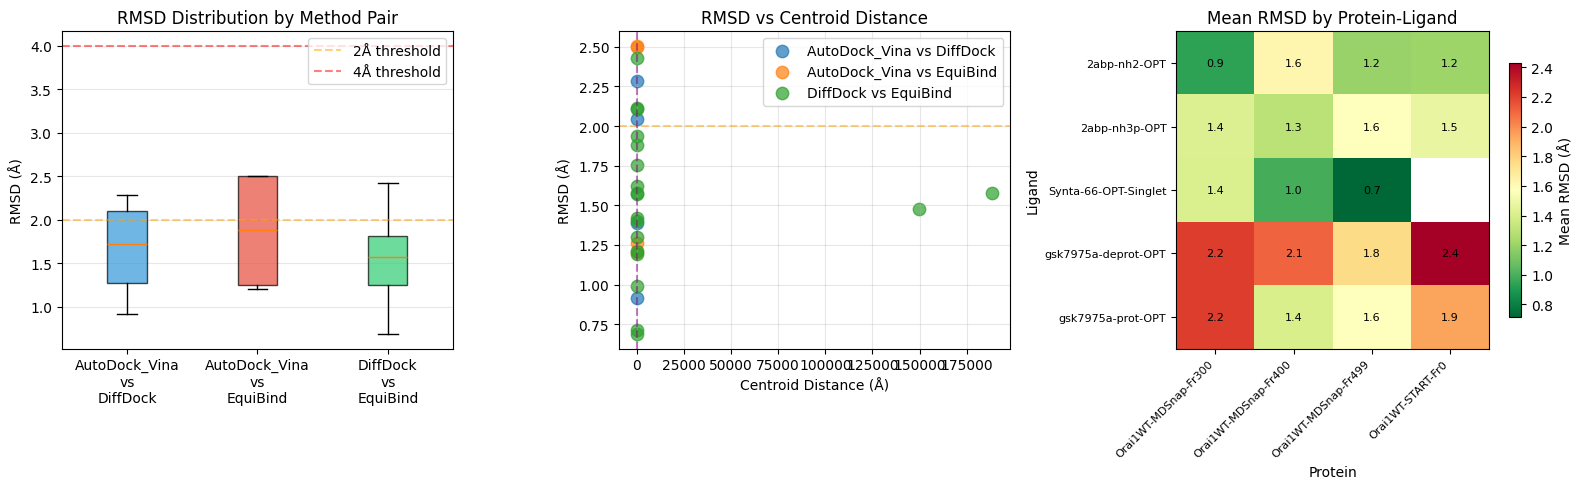


Visualization saved to: /home/manndo/MasterProject/posebusters_results/cross_method_rmsd_visualization.png


In [6]:
"""
Visualization: RMSD Distribution and Heatmap
"""
import matplotlib.pyplot as plt
import numpy as np

if 'df_comparison' in dir() and not df_comparison.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # 1. RMSD Distribution by Method Pair
    ax1 = axes[0]
    method_pairs = df_comparison.groupby(["Method_1", "Method_2"])["RMSD_Angstrom"].apply(list)
    
    data_to_plot = []
    labels = []
    for (m1, m2), rmsds in method_pairs.items():
        data_to_plot.append(rmsds)
        labels.append(f"{m1}\nvs\n{m2}")
    
    bp = ax1.boxplot(data_to_plot, labels=labels, patch_artist=True)
    colors = ['#3498db', '#e74c3c', '#2ecc71'][:len(data_to_plot)]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax1.axhline(y=2.0, color='orange', linestyle='--', alpha=0.5, label='2Å threshold')
    ax1.axhline(y=4.0, color='red', linestyle='--', alpha=0.5, label='4Å threshold')
    ax1.set_ylabel("RMSD (Å)")
    ax1.set_title("RMSD Distribution by Method Pair")
    ax1.legend(loc='upper right')
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. RMSD vs Centroid Distance Scatter
    ax2 = axes[1]
    if "Centroid_Distance_Angstrom" in df_comparison.columns:
        valid_data = df_comparison.dropna(subset=["Centroid_Distance_Angstrom"])
        if not valid_data.empty:
            for (m1, m2), group in valid_data.groupby(["Method_1", "Method_2"]):
                ax2.scatter(group["Centroid_Distance_Angstrom"], group["RMSD_Angstrom"], 
                           label=f"{m1} vs {m2}", alpha=0.7, s=80)
            
            ax2.axhline(y=2.0, color='orange', linestyle='--', alpha=0.5)
            ax2.axvline(x=5.0, color='purple', linestyle='--', alpha=0.5)
            ax2.set_xlabel("Centroid Distance (Å)")
            ax2.set_ylabel("RMSD (Å)")
            ax2.set_title("RMSD vs Centroid Distance")
            ax2.legend()
            ax2.grid(alpha=0.3)
    
    # 3. Heatmap: RMSD by Protein-Ligand Combination
    ax3 = axes[2]
    
    # Pivot table for heatmap
    pivot_data = df_comparison.pivot_table(
        values="RMSD_Angstrom", 
        index="Ligand", 
        columns="Protein",
        aggfunc='mean'
    )
    
    if not pivot_data.empty:
        im = ax3.imshow(pivot_data.values, cmap='RdYlGn_r', aspect='auto')
        
        ax3.set_xticks(range(len(pivot_data.columns)))
        ax3.set_yticks(range(len(pivot_data.index)))
        ax3.set_xticklabels(pivot_data.columns, rotation=45, ha='right', fontsize=8)
        ax3.set_yticklabels(pivot_data.index, fontsize=8)
        
        # Add text annotations
        for i in range(len(pivot_data.index)):
            for j in range(len(pivot_data.columns)):
                val = pivot_data.values[i, j]
                if not np.isnan(val):
                    ax3.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8,
                            color='white' if val > 3 else 'black')
        
        cbar = plt.colorbar(im, ax=ax3, shrink=0.8)
        cbar.set_label("Mean RMSD (Å)")
        ax3.set_title("Mean RMSD by Protein-Ligand")
        ax3.set_xlabel("Protein")
        ax3.set_ylabel("Ligand")
    
    plt.tight_layout()
    plt.savefig(output_dir / "cross_method_rmsd_visualization.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nVisualization saved to: {output_dir / 'cross_method_rmsd_visualization.png'}")
    
else:
    print("No comparison data available for visualization.")

In [7]:
"""
Top 3 Poses Comparison Table: RMSD Differences Between Docking Methods
Creates an overview showing how the best poses from each method compare in Angstroms
"""
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from itertools import combinations, product
import re

# ============================================================================
# COLLECT TOP 3 POSES FROM EACH METHOD
# ============================================================================

def get_pose_rank(filename):
    """Extract rank number from pose filename for sorting"""
    name = Path(filename).stem.lower()
    
    # DiffDock: rank1.sdf, rank2.sdf, rank1_confidence_X.XX.sdf
    match = re.search(r'rank(\d+)', name)
    if match:
        return int(match.group(1))
    
    # AutoDock: model1, model2, etc. (model1 = best)
    match = re.search(r'model(\d+)', name)
    if match:
        return int(match.group(1))
    
    # EquiBind: pose_01.sdf, pose_02.sdf
    match = re.search(r'pose[_-]?(\d+)', name)
    if match:
        return int(match.group(1))
    
    # Generic numbered files
    match = re.search(r'(\d+)', name)
    if match:
        return int(match.group(1))
    
    return 999  # Default for unknown format


def collect_top3_poses():
    """Collect top 3 poses from each method for each protein-ligand combination"""
    poses_by_combo = defaultdict(lambda: defaultdict(list))
    
    # AutoDock Vina (converted SDF files)
    if converted_dir.exists():
        for sdf_file in converted_dir.glob("*.sdf"):
            stem = sdf_file.stem
            if "_vina_out_model" in stem:
                base = stem.split("_vina_out_model")[0]
                parts = base.split("__")
                if len(parts) == 2:
                    protein, ligand = parts
                    poses_by_combo[(protein, ligand)]["AutoDock_Vina"].append(str(sdf_file))
    
    # DiffDock (native SDF files)
    diffdock_path = Path(diffdock_poses_dir)
    for subdir in diffdock_path.iterdir():
        if not subdir.is_dir():
            continue
        if "_ligand__" in subdir.name or subdir.name in ["prepared_proteins", "converted_pdbqt"]:
            continue
        
        parts = subdir.name.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            for sdf_file in subdir.glob("**/*.sdf"):
                poses_by_combo[(protein, ligand)]["DiffDock"].append(str(sdf_file))
    
    # EquiBind (native SDF files) - exclude pymol variants
    equibind_path = Path(equibind_poses_dir)
    for subdir in equibind_path.iterdir():
        if not subdir.is_dir() or "_pymol" in subdir.name:
            continue
        
        parts = subdir.name.split("__")
        if len(parts) == 2:
            ligand, protein = parts
            for sdf_file in subdir.glob("*.sdf"):
                poses_by_combo[(protein, ligand)]["EquiBind"].append(str(sdf_file))
    
    # Sort by rank and take top 3 from each method
    top3_poses = defaultdict(lambda: defaultdict(list))
    for (protein, ligand), methods in poses_by_combo.items():
        for method, files in methods.items():
            sorted_files = sorted(files, key=get_pose_rank)
            top3_poses[(protein, ligand)][method] = sorted_files[:3]
    
    return top3_poses


# ============================================================================
# CALCULATE PAIRWISE RMSD FOR TOP 3 POSES
# ============================================================================

print("=" * 120)
print("TOP 3 POSES COMPARISON: RMSD Between Docking Methods (in Angstroms)")
print("=" * 120)

# Collect top 3 poses
top3_poses = collect_top3_poses()

# Filter to combinations with multiple methods
multi_method_combos = {
    k: v for k, v in top3_poses.items() 
    if len(v) > 1
}

print(f"\nProtein-ligand combinations with multiple methods: {len(multi_method_combos)}")

# Store all comparison results
all_comparisons = []

for (protein, ligand), methods_poses in sorted(multi_method_combos.items()):
    methods = list(methods_poses.keys())
    
    # Compare each pair of methods
    for method1, method2 in combinations(methods, 2):
        poses1 = methods_poses[method1]
        poses2 = methods_poses[method2]
        
        # Calculate RMSD between top poses from each method
        for i, pose1_file in enumerate(poses1, 1):
            mol1 = load_molecule_from_sdf(pose1_file)
            if mol1 is None:
                continue
            
            for j, pose2_file in enumerate(poses2, 1):
                mol2 = load_molecule_from_sdf(pose2_file)
                if mol2 is None:
                    continue
                
                rmsd = calculate_rmsd(mol1, mol2, align=True)
                centroid_dist = calculate_centroid_distance(mol1, mol2)
                
                if rmsd is not None:
                    all_comparisons.append({
                        "Protein": protein,
                        "Ligand": ligand,
                        "Method_1": method1,
                        "Pose_1_Rank": i,
                        "Method_2": method2,
                        "Pose_2_Rank": j,
                        "RMSD_Å": round(rmsd, 2),
                        "Centroid_Δ_Å": round(centroid_dist, 2) if centroid_dist else None,
                    })

# Create DataFrame
df_top3 = pd.DataFrame(all_comparisons)

if not df_top3.empty:
    # ============================================================================
    # OVERVIEW TABLE 1: Best Pose vs Best Pose (Rank 1 vs Rank 1)
    # ============================================================================
    print("\n" + "=" * 120)
    print("TABLE 1: BEST POSE COMPARISON (Rank 1 vs Rank 1)")
    print("=" * 120)
    
    df_rank1 = df_top3[(df_top3["Pose_1_Rank"] == 1) & (df_top3["Pose_2_Rank"] == 1)]
    
    # Pivot to show all method pairs
    rank1_pivot = df_rank1.pivot_table(
        values="RMSD_Å",
        index=["Protein", "Ligand"],
        columns=["Method_1", "Method_2"],
        aggfunc='first'
    )
    
    # Flatten column names
    rank1_pivot.columns = [f"{m1} vs {m2}" for m1, m2 in rank1_pivot.columns]
    rank1_pivot = rank1_pivot.reset_index()
    
    print(rank1_pivot.to_string(index=False))
    
    # ============================================================================
    # OVERVIEW TABLE 2: All Top 3 Comparisons Summary
    # ============================================================================
    print("\n" + "=" * 120)
    print("TABLE 2: TOP 3 POSES DETAILED COMPARISON")
    print("=" * 120)
    
    # Show comparison label
    df_top3["Comparison"] = df_top3.apply(
        lambda r: f"{r['Method_1']}#{r['Pose_1_Rank']} vs {r['Method_2']}#{r['Pose_2_Rank']}", 
        axis=1
    )
    
    # Group by protein-ligand and show summary
    for (protein, ligand), group in df_top3.groupby(["Protein", "Ligand"]):
        print(f"\n{'─'*80}")
        print(f"  {protein} + {ligand}")
        print(f"{'─'*80}")
        
        # Pivot: rows are Method1 poses, columns are Method2 poses
        for (m1, m2), subgroup in group.groupby(["Method_1", "Method_2"]):
            pivot = subgroup.pivot(
                index="Pose_1_Rank",
                columns="Pose_2_Rank",
                values="RMSD_Å"
            )
            pivot.index = [f"{m1} Rank {i}" for i in pivot.index]
            pivot.columns = [f"{m2} Rank {j}" for j in pivot.columns]
            
            print(f"\n  {m1} vs {m2} (RMSD in Å):")
            print(pivot.to_string())
    
    # ============================================================================
    # OVERVIEW TABLE 3: Summary Statistics by Method Pair
    # ============================================================================
    print("\n" + "=" * 120)
    print("TABLE 3: SUMMARY STATISTICS - ALL TOP 3 POSE COMPARISONS")
    print("=" * 120)
    
    summary_stats = df_top3.groupby(["Method_1", "Method_2"]).agg({
        "RMSD_Å": ["count", "mean", "std", "min", "max", "median"]
    }).round(2)
    summary_stats.columns = ["N_Comparisons", "Mean_RMSD", "Std_RMSD", "Min_RMSD", "Max_RMSD", "Median_RMSD"]
    summary_stats = summary_stats.reset_index()
    summary_stats["Method_Pair"] = summary_stats["Method_1"] + " vs " + summary_stats["Method_2"]
    summary_stats = summary_stats[["Method_Pair", "N_Comparisons", "Mean_RMSD", "Std_RMSD", "Min_RMSD", "Max_RMSD", "Median_RMSD"]]
    
    print(summary_stats.to_string(index=False))
    
    # ============================================================================
    # OVERVIEW TABLE 4: Compact Overview with Min/Mean/Max RMSD
    # ============================================================================
    print("\n" + "=" * 120)
    print("TABLE 4: COMPACT OVERVIEW - RMSD RANGE FOR TOP 3 POSES (Min | Mean | Max)")
    print("=" * 120)
    
    compact_data = []
    for (protein, ligand), group in df_top3.groupby(["Protein", "Ligand"]):
        row = {"Protein": protein, "Ligand": ligand}
        
        for (m1, m2), subgroup in group.groupby(["Method_1", "Method_2"]):
            rmsds = subgroup["RMSD_Å"].values
            pair_name = f"{m1}_vs_{m2}"
            row[f"{pair_name}_Min"] = round(rmsds.min(), 2)
            row[f"{pair_name}_Mean"] = round(rmsds.mean(), 2)
            row[f"{pair_name}_Max"] = round(rmsds.max(), 2)
            row[f"{pair_name}_Range"] = f"{rmsds.min():.1f} | {rmsds.mean():.1f} | {rmsds.max():.1f}"
        
        compact_data.append(row)
    
    df_compact = pd.DataFrame(compact_data)
    
    # Show only Range columns for compact view
    range_cols = ["Protein", "Ligand"] + [c for c in df_compact.columns if "_Range" in c]
    df_compact_display = df_compact[range_cols].copy()
    df_compact_display.columns = [c.replace("_Range", "").replace("_vs_", " vs ") for c in df_compact_display.columns]
    
    print(df_compact_display.to_string(index=False))
    
    # ============================================================================
    # INTERPRETATION
    # ============================================================================
    print("\n" + "=" * 120)
    print("INTERPRETATION")
    print("=" * 120)
    print("""
   Format: Min | Mean | Max RMSD (in Angstroms)
   
   Color Coding Guide:
   • Green  (< 2 Å)  : Methods agree well - similar binding poses
   • Yellow (2-4 Å)  : Moderate agreement - similar pocket, different orientation  
   • Red    (> 4 Å)  : Methods disagree - potentially different binding sites
   
   What this means:
   • Low RMSD across all top 3 poses → High confidence in binding mode
   • High RMSD between methods → Binding site uncertain, need experimental validation
   • Large range (Max - Min) → Poses within method are diverse
    """)
    
    # Save results
    output_file = output_dir / "top3_poses_comparison.csv"
    df_top3.to_csv(output_file, index=False)
    
    compact_file = output_dir / "top3_poses_compact_overview.csv"
    df_compact.to_csv(compact_file, index=False)
    
    print(f"\n   Detailed results saved to: {output_file}")
    print(f"   Compact overview saved to: {compact_file}")

else:
    print("\n   No pose comparisons could be made. Check that:")
    print("   - SDF files exist and are valid")
    print("   - Molecules have matching atom counts")
    print("   - Multiple docking methods were used for the same protein-ligand pairs")

print("\n" + "=" * 120)
print("Done!")
print("=" * 120)

TOP 3 POSES COMPARISON: RMSD Between Docking Methods (in Angstroms)

Protein-ligand combinations with multiple methods: 19

TABLE 1: BEST POSE COMPARISON (Rank 1 vs Rank 1)
             Protein               Ligand  AutoDock_Vina vs DiffDock  AutoDock_Vina vs EquiBind  DiffDock vs EquiBind
Orai1WT-MDSnap-Fr300         2abp-nh2-OPT                       1.32                       1.42                  0.57
Orai1WT-MDSnap-Fr300        2abp-nh3p-OPT                        NaN                        NaN                  0.82
Orai1WT-MDSnap-Fr300 Synta-66-OPT-Singlet                       1.28                       1.26                  1.26
Orai1WT-MDSnap-Fr300  gsk7975a-deprot-OPT                       1.35                       1.81                  1.46
Orai1WT-MDSnap-Fr300    gsk7975a-prot-OPT                       2.53                       2.18                  2.00
Orai1WT-MDSnap-Fr400         2abp-nh2-OPT                        NaN                        NaN                  1.17
O

In [8]:
"""
Summary Statistics and Comparison by Docking Method
"""
# Set pandas display options to show full output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

if not results_df.empty:
    # Key boolean columns from PoseBusters
    bool_cols = [
        'mol_pred_loaded', 'sanitization', 'all_atoms_connected', 
        'bond_lengths', 'bond_angles', 'internal_steric_clash',
        'aromatic_ring_flatness', 'double_bond_flatness',
        'internal_energy', 'passes_all'  # Note: column names may vary
    ]
    
    # Filter to only columns that exist
    available_bool_cols = [c for c in bool_cols if c in results_df.columns]
    
    print("=" * 60)
    print("SUMMARY BY DOCKING METHOD")
    print("=" * 60)
    
    # Group by method and calculate pass rates
    if available_bool_cols:
        summary = results_df.groupby("docking_method")[available_bool_cols].mean() * 100
        print("\nPass rates (%) for each check:")
        print(summary.round(1).to_string())
    else:
        print("No boolean check columns found in results.")
    
    # Count poses by method
    print("\n" + "-" * 60)
    print("Pose counts by method:")
    print(results_df.groupby("docking_method").size().to_string())
    
    # Count poses by protein-ligand combination
    print("\n" + "-" * 60)
    print("Pose counts by protein-ligand-method:")
    pivot_table = results_df.groupby(["docking_method", "protein", "ligand"]).size().unstack(fill_value=0)
    print(pivot_table.to_string())
    
else:
    print("No results available for summary.")

SUMMARY BY DOCKING METHOD

Pass rates (%) for each check:
                mol_pred_loaded  sanitization  all_atoms_connected  bond_lengths  bond_angles  internal_steric_clash  aromatic_ring_flatness  double_bond_flatness  internal_energy
docking_method                                                                                                                                                                     
autodock                  100.0         100.0                100.0         100.0        100.0                  100.0                   100.0                 100.0            100.0
diffdock                  100.0         100.0                100.0          99.1        100.0                   94.5                   100.0                 100.0             98.2
equibind                  100.0         100.0                100.0         100.0        100.0                   83.8                   100.0                 100.0             85.3

-----------------------------------------

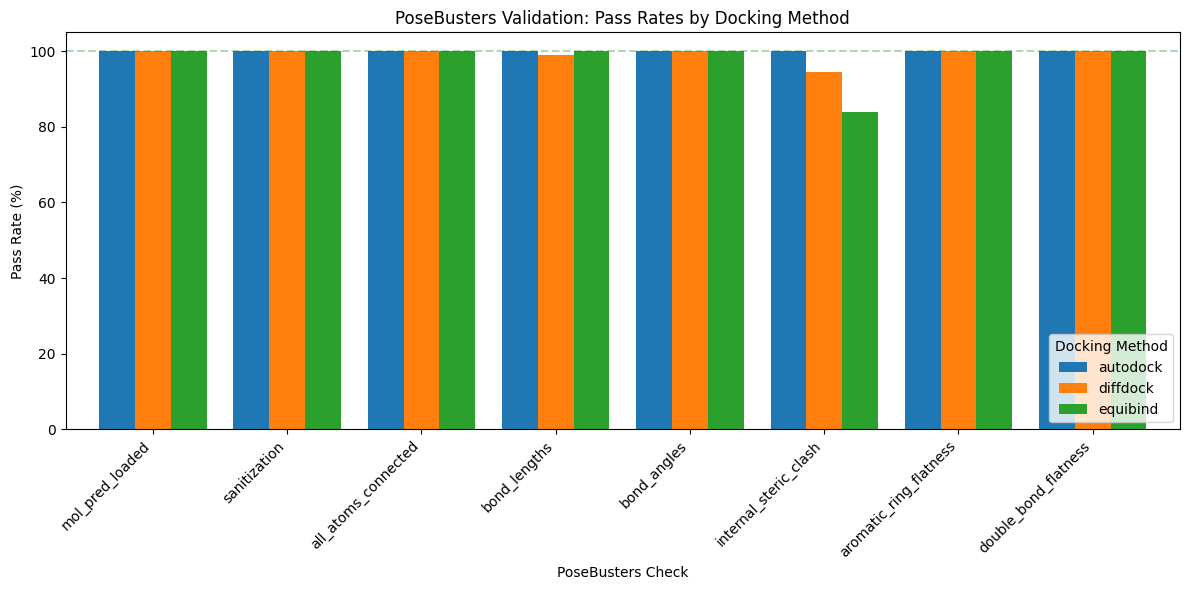


Figure saved to: /home/manndo/MasterProject/posebusters_results/posebusters_comparison.png


In [9]:
"""
Visualization: Compare pass rates across docking methods
"""
import matplotlib.pyplot as plt

if not results_df.empty:
    # Key boolean columns to visualize
    key_checks = [
        'mol_pred_loaded', 'sanitization', 'all_atoms_connected',
        'bond_lengths', 'bond_angles', 'internal_steric_clash',
        'aromatic_ring_flatness', 'double_bond_flatness'
    ]
    
    # Filter to available columns
    available_checks = [c for c in key_checks if c in results_df.columns]
    
    if available_checks:
        # Calculate pass rates by method
        pass_rates = results_df.groupby("docking_method")[available_checks].mean() * 100
        
        # Create bar chart
        fig, ax = plt.subplots(figsize=(12, 6))
        pass_rates.T.plot(kind='bar', ax=ax, width=0.8)
        
        ax.set_ylabel("Pass Rate (%)")
        ax.set_xlabel("PoseBusters Check")
        ax.set_title("PoseBusters Validation: Pass Rates by Docking Method")
        ax.legend(title="Docking Method", loc='lower right')
        ax.set_ylim(0, 105)
        ax.axhline(y=100, color='green', linestyle='--', alpha=0.3, label='100%')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(output_dir / "posebusters_comparison.png", dpi=150)
        plt.show()
        
        print(f"\nFigure saved to: {output_dir / 'posebusters_comparison.png'}")
    else:
        print("No check columns available for visualization.")
else:
    print("No results available for visualization.")

Found 19 protein-ligand combinations
Found 3 method pairs: ['AutoDock_Vina vs DiffDock', 'AutoDock_Vina vs EquiBind', 'DiffDock vs EquiBind']


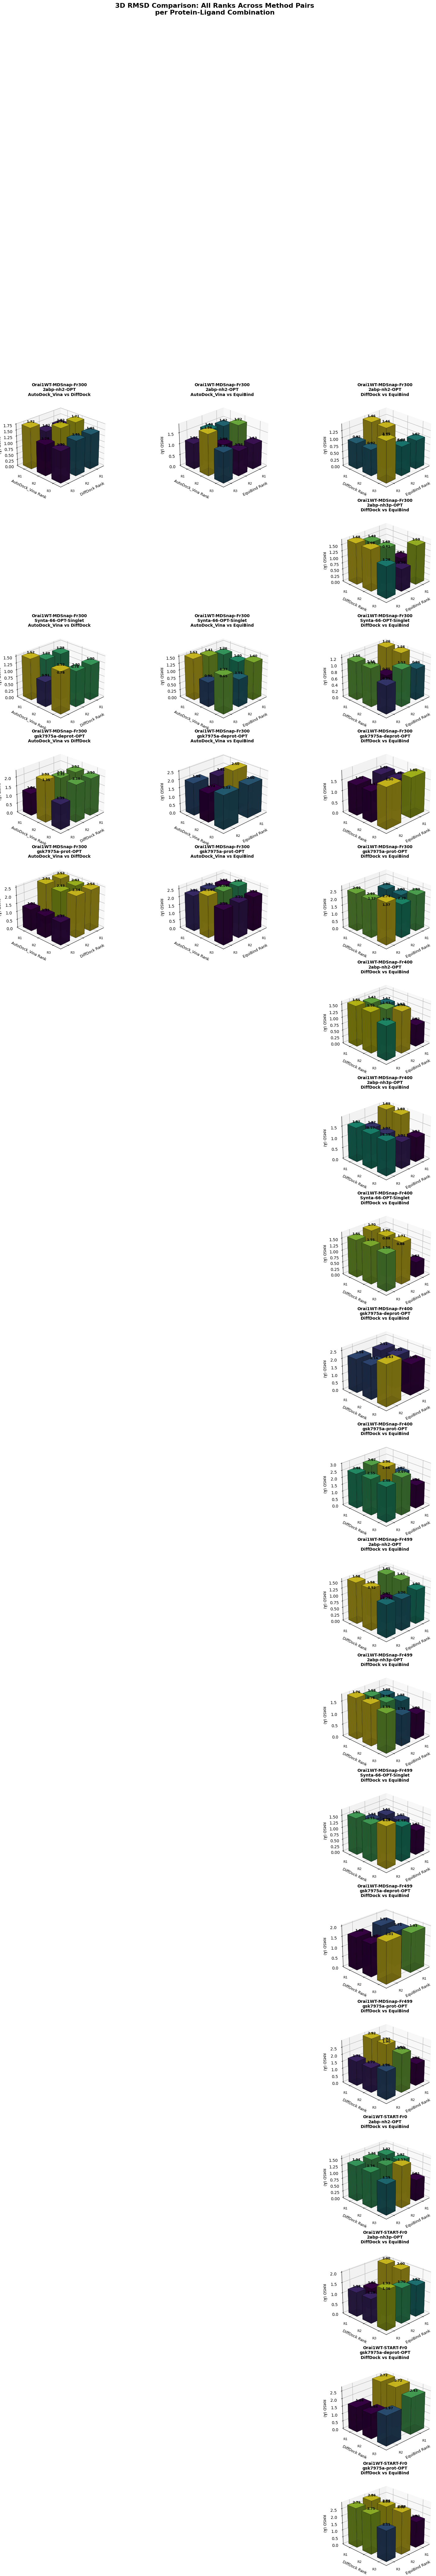


Figure saved to: /home/manndo/MasterProject/posebusters_results/3d_rmsd_per_combination.png


In [10]:
# 3D Visualization: RMSD Comparison Across All Docking Method Pairs
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# ============================================================================
# PART 1: 3D HEATMAPS FOR EACH PROTEIN-LIGAND COMBINATION & METHOD PAIR
# ============================================================================

if not df_top3.empty:
    # Get unique protein-ligand combinations and method pairs
    combos = df_top3.groupby(["Protein", "Ligand"]).size().reset_index()[["Protein", "Ligand"]]
    method_pairs = df_top3.groupby(["Method_1", "Method_2"]).size().reset_index()[["Method_1", "Method_2"]]
    
    print(f"Found {len(combos)} protein-ligand combinations")
    print(f"Found {len(method_pairs)} method pairs: {[f'{r.Method_1} vs {r.Method_2}' for _, r in method_pairs.iterrows()]}")
    
    # Calculate number of subplots needed
    n_combos = len(combos)
    n_pairs = len(method_pairs)
    
    # Create figure with subplots for each protein-ligand combination
    fig = plt.figure(figsize=(6 * n_pairs + 2, 5 * n_combos))
    
    subplot_idx = 1
    for combo_idx, (_, combo_row) in enumerate(combos.iterrows()):
        protein = combo_row["Protein"]
        ligand = combo_row["Ligand"]
        
        for pair_idx, (_, pair_row) in enumerate(method_pairs.iterrows()):
            m1, m2 = pair_row["Method_1"], pair_row["Method_2"]
            
            # Filter data for this combination and method pair
            subset = df_top3[
                (df_top3["Protein"] == protein) & 
                (df_top3["Ligand"] == ligand) &
                (df_top3["Method_1"] == m1) & 
                (df_top3["Method_2"] == m2)
            ]
            
            if subset.empty:
                subplot_idx += 1
                continue
            
            # Create RMSD matrix (Method 1 ranks vs Method 2 ranks)
            max_rank_1 = int(subset["Pose_1_Rank"].max())
            max_rank_2 = int(subset["Pose_2_Rank"].max())
            rmsd_matrix = np.full((max_rank_1, max_rank_2), np.nan)
            
            for _, row in subset.iterrows():
                i = int(row["Pose_1_Rank"]) - 1
                j = int(row["Pose_2_Rank"]) - 1
                rmsd_matrix[i, j] = row["RMSD_Å"]
            
            # Create 3D subplot
            ax = fig.add_subplot(n_combos, n_pairs, subplot_idx, projection='3d')
            
            # Create meshgrid
            x_pos = np.arange(max_rank_2)
            y_pos = np.arange(max_rank_1)
            X, Y = np.meshgrid(x_pos, y_pos)
            
            # Flatten for bar3d
            x_flat = X.flatten()
            y_flat = Y.flatten()
            z_flat = np.zeros_like(x_flat, dtype=float)
            dz = rmsd_matrix.flatten()
            
            # Handle NaN values
            valid_mask = ~np.isnan(dz)
            if not valid_mask.any():
                subplot_idx += 1
                continue
            
            dx = dy = 0.6
            
            # Create colors based on RMSD values
            valid_dz = dz[valid_mask]
            norm = plt.Normalize(vmin=np.nanmin(dz), vmax=np.nanmax(dz))
            colors = cm.viridis(norm(dz))
            
            # Plot 3D bars
            ax.bar3d(x_flat[valid_mask], y_flat[valid_mask], z_flat[valid_mask], 
                    dx, dy, dz[valid_mask], color=colors[valid_mask], alpha=0.9, 
                    edgecolor='black', linewidth=0.3)
            
            # Add value labels
            for i in range(max_rank_1):
                for j in range(max_rank_2):
                    if not np.isnan(rmsd_matrix[i, j]):
                        ax.text(j + dx/2, i + dy/2, rmsd_matrix[i, j] + 0.05, 
                                f'{rmsd_matrix[i, j]:.2f}', 
                                ha='center', va='bottom', fontsize=8, fontweight='bold')
            
            # Labels
            ax.set_xlabel(f'{m2} Rank', fontsize=9)
            ax.set_ylabel(f'{m1} Rank', fontsize=9)
            ax.set_zlabel('RMSD (Å)', fontsize=9)
            ax.set_xticks(x_pos + dx/2)
            ax.set_xticklabels([f'R{i+1}' for i in range(max_rank_2)], fontsize=8)
            ax.set_yticks(y_pos + dy/2)
            ax.set_yticklabels([f'R{i+1}' for i in range(max_rank_1)], fontsize=8)
            ax.set_title(f'{protein}\n{ligand}\n{m1} vs {m2}', fontsize=10, fontweight='bold')
            ax.view_init(elev=25, azim=45)
            
            subplot_idx += 1
    
    plt.suptitle('3D RMSD Comparison: All Ranks Across Method Pairs\nper Protein-Ligand Combination', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(output_dir / "3d_rmsd_per_combination.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nFigure saved to: {output_dir / '3d_rmsd_per_combination.png'}")

else:
    print("No comparison data available for visualization.")

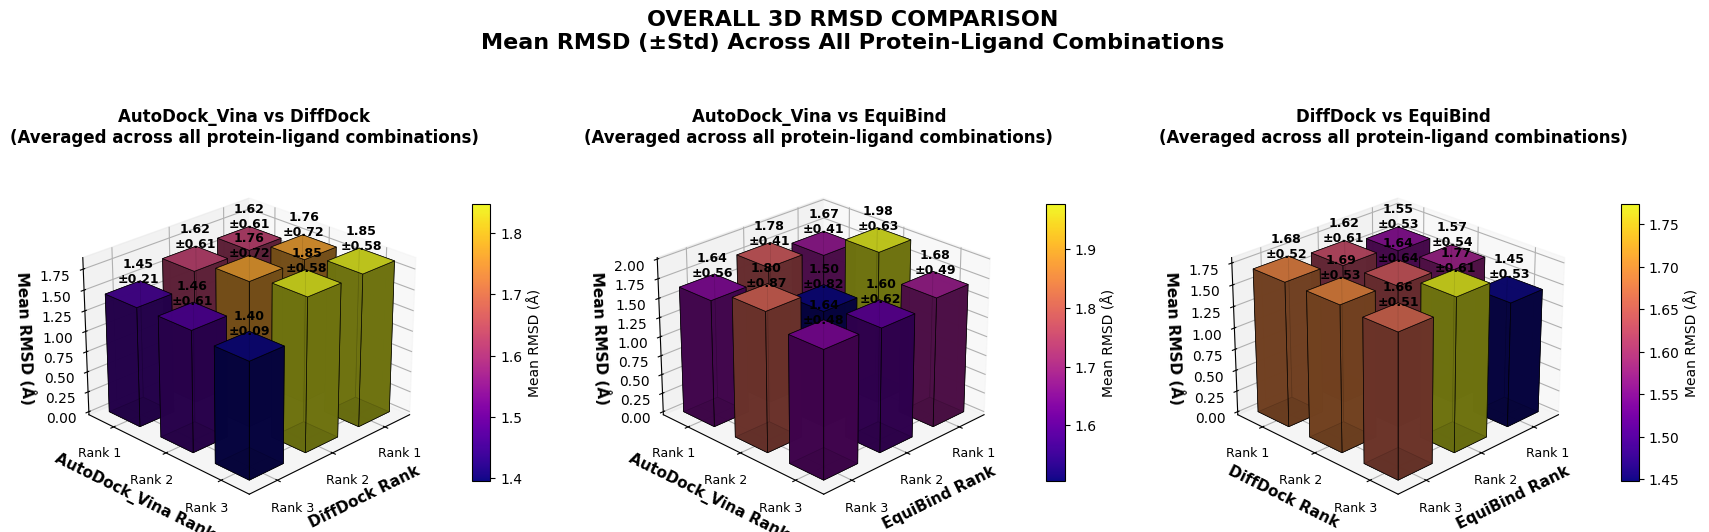


Figure saved to: /home/manndo/MasterProject/posebusters_results/3d_rmsd_overall_comparison.png

OVERALL MEAN RMSD COMPARISON MATRICES (Averaged Across All Combinations)

AutoDock_Vina vs DiffDock (RMSD in Å) - Averaged over 4 protein-ligand combinations:
                      DiffDock Rank 1  DiffDock Rank 2  DiffDock Rank 3
AutoDock_Vina Rank 1             1.62             1.62             1.45
AutoDock_Vina Rank 2             1.76             1.76             1.46
AutoDock_Vina Rank 3             1.85             1.85             1.40

AutoDock_Vina vs EquiBind (RMSD in Å) - Averaged over 4 protein-ligand combinations:
                      EquiBind Rank 1  EquiBind Rank 2  EquiBind Rank 3
AutoDock_Vina Rank 1             1.67             1.78             1.64
AutoDock_Vina Rank 2             1.98             1.50             1.80
AutoDock_Vina Rank 3             1.68             1.60             1.64

DiffDock vs EquiBind (RMSD in Å) - Averaged over 19 protein-ligand combinations:


In [11]:
# ============================================================================
# PART 2: OVERALL 3D COMPARISON - Aggregated Across ALL Protein-Ligand Combinations
# ============================================================================

if not df_top3.empty:
    # Get unique method pairs
    method_pairs = df_top3.groupby(["Method_1", "Method_2"]).size().reset_index()[["Method_1", "Method_2"]]
    n_pairs = len(method_pairs)
    
    # Create figure with one 3D plot per method pair
    fig = plt.figure(figsize=(7 * n_pairs, 6))
    
    for pair_idx, (_, pair_row) in enumerate(method_pairs.iterrows()):
        m1, m2 = pair_row["Method_1"], pair_row["Method_2"]
        
        # Filter data for this method pair
        subset = df_top3[(df_top3["Method_1"] == m1) & (df_top3["Method_2"] == m2)]
        
        if subset.empty:
            continue
        
        # Calculate MEAN RMSD matrix across all protein-ligand combinations
        mean_rmsd = subset.groupby(["Pose_1_Rank", "Pose_2_Rank"])["RMSD_Å"].mean().reset_index()
        
        max_rank_1 = int(mean_rmsd["Pose_1_Rank"].max())
        max_rank_2 = int(mean_rmsd["Pose_2_Rank"].max())
        rmsd_matrix = np.full((max_rank_1, max_rank_2), np.nan)
        std_matrix = np.full((max_rank_1, max_rank_2), np.nan)
        
        # Also get standard deviation
        std_rmsd = subset.groupby(["Pose_1_Rank", "Pose_2_Rank"])["RMSD_Å"].std().reset_index()
        
        for _, row in mean_rmsd.iterrows():
            i = int(row["Pose_1_Rank"]) - 1
            j = int(row["Pose_2_Rank"]) - 1
            rmsd_matrix[i, j] = row["RMSD_Å"]
        
        for _, row in std_rmsd.iterrows():
            i = int(row["Pose_1_Rank"]) - 1
            j = int(row["Pose_2_Rank"]) - 1
            std_matrix[i, j] = row["RMSD_Å"]
        
        # Create 3D subplot
        ax = fig.add_subplot(1, n_pairs, pair_idx + 1, projection='3d')
        
        # Create meshgrid
        x_pos = np.arange(max_rank_2)
        y_pos = np.arange(max_rank_1)
        X, Y = np.meshgrid(x_pos, y_pos)
        
        # Flatten for bar3d
        x_flat = X.flatten()
        y_flat = Y.flatten()
        z_flat = np.zeros_like(x_flat, dtype=float)
        dz = rmsd_matrix.flatten()
        
        # Handle NaN values
        valid_mask = ~np.isnan(dz)
        dx = dy = 0.6
        
        # Create colors
        norm = plt.Normalize(vmin=np.nanmin(dz), vmax=np.nanmax(dz))
        colors = cm.plasma(norm(dz))
        
        # Plot 3D bars
        ax.bar3d(x_flat[valid_mask], y_flat[valid_mask], z_flat[valid_mask], 
                dx, dy, dz[valid_mask], color=colors[valid_mask], alpha=0.9, 
                edgecolor='black', linewidth=0.5)
        
        # Add value labels with mean ± std
        for i in range(max_rank_1):
            for j in range(max_rank_2):
                if not np.isnan(rmsd_matrix[i, j]):
                    std_val = std_matrix[i, j] if not np.isnan(std_matrix[i, j]) else 0
                    label = f'{rmsd_matrix[i, j]:.2f}\n±{std_val:.2f}'
                    ax.text(j + dx/2, i + dy/2, rmsd_matrix[i, j] + 0.1, 
                            label, ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Labels
        ax.set_xlabel(f'{m2} Rank', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'{m1} Rank', fontsize=11, fontweight='bold')
        ax.set_zlabel('Mean RMSD (Å)', fontsize=11, fontweight='bold')
        ax.set_xticks(x_pos + dx/2)
        ax.set_xticklabels([f'Rank {i+1}' for i in range(max_rank_2)], fontsize=9)
        ax.set_yticks(y_pos + dy/2)
        ax.set_yticklabels([f'Rank {i+1}' for i in range(max_rank_1)], fontsize=9)
        ax.set_title(f'{m1} vs {m2}\n(Averaged across all protein-ligand combinations)', 
                    fontsize=12, fontweight='bold', pad=15)
        ax.view_init(elev=25, azim=45)
        
        # Add colorbar
        sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.6, aspect=15, pad=0.1)
        cbar.set_label('Mean RMSD (Å)', fontsize=10)
    
    plt.suptitle('OVERALL 3D RMSD COMPARISON\nMean RMSD (±Std) Across All Protein-Ligand Combinations', 
                 fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(output_dir / "3d_rmsd_overall_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nFigure saved to: {output_dir / '3d_rmsd_overall_comparison.png'}")
    
    # ============================================================================
    # Print summary table for the overall comparison
    # ============================================================================
    print("\n" + "=" * 100)
    print("OVERALL MEAN RMSD COMPARISON MATRICES (Averaged Across All Combinations)")
    print("=" * 100)
    
    for _, pair_row in method_pairs.iterrows():
        m1, m2 = pair_row["Method_1"], pair_row["Method_2"]
        subset = df_top3[(df_top3["Method_1"] == m1) & (df_top3["Method_2"] == m2)]
        
        if subset.empty:
            continue
        
        mean_pivot = subset.pivot_table(
            values="RMSD_Å", 
            index="Pose_1_Rank", 
            columns="Pose_2_Rank", 
            aggfunc='mean'
        ).round(2)
        
        mean_pivot.index = [f"{m1} Rank {i}" for i in mean_pivot.index]
        mean_pivot.columns = [f"{m2} Rank {j}" for j in mean_pivot.columns]
        
        n_combos = subset.groupby(["Protein", "Ligand"]).ngroups
        
        print(f"\n{m1} vs {m2} (RMSD in Å) - Averaged over {n_combos} protein-ligand combinations:")
        print(mean_pivot.to_string())

else:
    print("No comparison data available for overall visualization.")